In [1]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
import numpy as np
import xarray as xr

ds = xr.open_mfdataset("../data/interim/*.nc", chunks={"valid_time": 365})

/tmp/ipykernel_128595/801793702.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset("../data/interim/*.nc", chunks={"valid_time": 365})
/tmp/ipykernel_128595/801793702.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset("../data/interim/*.nc", chunks={"valid_time": 365})
/tmp/ipykernel_128595/801793702.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset("../data/interim/*.nc", chunks={"valid_time": 365})
/tmp/ipykernel_128595/801793702.py:5: UserWarning: The specified chunks separate the sto

In [2]:
# multiple tp with 1000 for mm values
ds["tp"] = ds["tp"] * 1000
ds["tp"].attrs["units"] = "mm"

ds

<xarray.Dataset> Size: 3GB
Dimensions:     (valid_time: 9132, latitude: 121, longitude: 121)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 73kB 2000-01-01 ... 2024-12-31
  * latitude    (latitude) float64 968B 35.0 34.75 34.5 34.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 968B 65.0 65.25 65.5 ... 94.5 94.75 95.0
Data variables:
    u10         (valid_time, latitude, longitude) float32 535MB dask.array<chunksize=(365, 61, 61), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 535MB dask.array<chunksize=(365, 61, 61), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 535MB dask.array<chunksize=(365, 61, 61), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 535MB dask.array<chunksize=(365, 61, 61), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 535MB dask.array<chunksize=(365, 61, 61), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-22T11:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
from constants import DATA_CONFIG

vars: list[str] = DATA_CONFIG["era5"]["parameters"]

In [4]:
# check all years
years = np.unique(ds["valid_time"].dt.year.values)
years

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024])

In [5]:
for var in vars:
    print(var.center(25, "-"))
    print(f"{var}: Min {ds[var].min().values}")
    print(f"{var}: Max {ds[var].max().values}")
    print(f"{var}: Mean {ds[var].mean().values}")
    print()

-----------u10-----------
u10: Min -24.724151611328125
u10: Max 25.767061233520508
u10: Mean 1.0826175212860107

-----------v10-----------
v10: Min -24.77762794494629
v10: Max 26.513349533081055
v10: Mean 0.1734369993209839

-----------d2m-----------
d2m: Min 220.58026123046875
d2m: Max 304.7151794433594
d2m: Mean 288.31121826171875

-----------t2m-----------
t2m: Min 230.87396240234375
t2m: Max 317.87042236328125
t2m: Mean 295.1584777832031

------------tp-----------
tp: Min 0.0
tp: Max 700.979248046875
tp: Mean 3.298840284347534



In [6]:
# check for null values
for var in vars:
    nan_count = ds[var].isnull().sum().values
    print(f"{var}: NaN {nan_count}")

u10: NaN 0
v10: NaN 0
d2m: NaN 0
t2m: NaN 0
tp: NaN 0


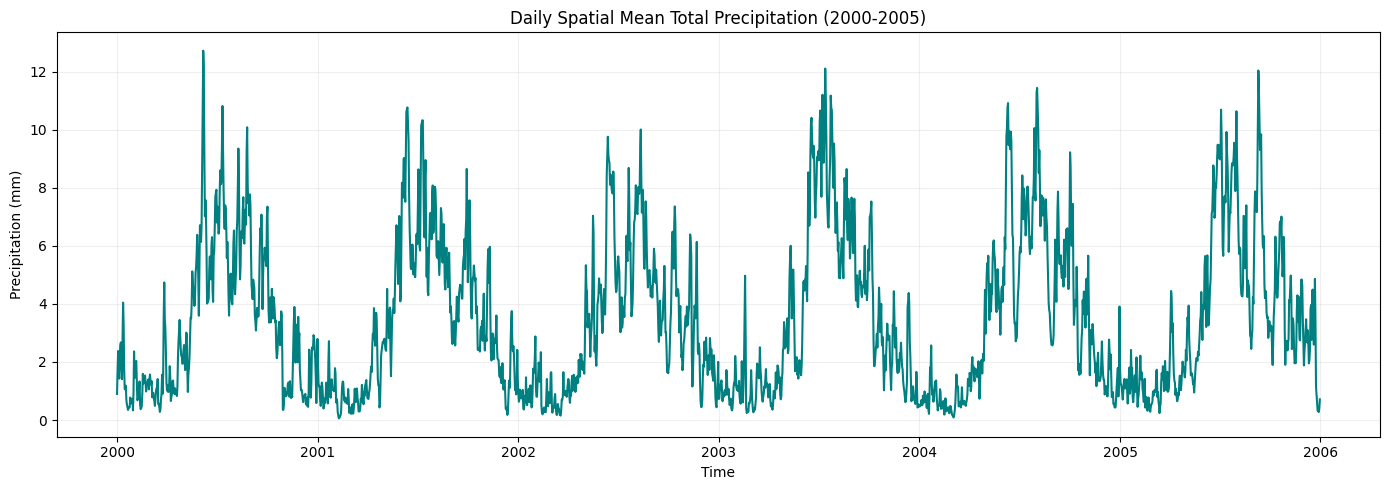

In [7]:
import matplotlib.pyplot as plt
spatial_mean_tp = ds["tp"].mean(dim=["latitude", "longitude"])

plt.figure(figsize=(14, 5))

spatial_mean_tp.sel(valid_time=slice("2000", "2005")).plot(color="teal")

plt.title("Daily Spatial Mean Total Precipitation (2000-2005)")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Time")
plt.grid(True, alpha=0.2)
plt.tight_layout()


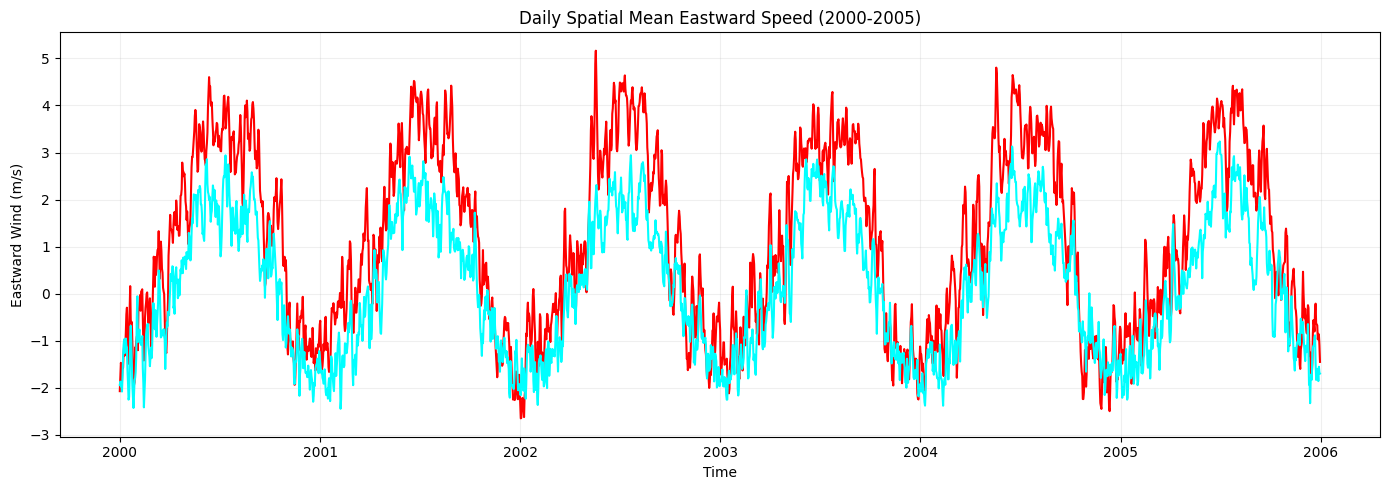

In [ ]:
spatial_mean_u10 = ds["u10"].mean(dim=["latitude", "longitude"])
# spatial_mean_v10 = ds["v10"].mean(dim=["latitude", "longitude"])

plt.figure(figsize=(14, 5))

spatial_mean_u10.sel(valid_time=slice("2000", "2005")).plot(color="red")
# spatial_mean_v10.sel(valid_time=slice("2000", "2005")).plot(color="cyan")

plt.title("Daily Spatial Mean Eastward Speed (2000-2005)")
plt.ylabel("Eastward Wind (m/s)")
plt.xlabel("Time")
plt.grid(True, alpha=0.2)
plt.tight_layout()